# Integración de Datos y Cálculo del Índice Alternativo

Este notebook consolida los datos objetivo de Oliver Wyman Forum (OWF) con los indicadores de ONU y OECD explorados anteriormente, y calcula el nuevo índice de prosperidad urbana alternativa centrado en la sostenibilidad y la equidad.

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler

# Encontrar la raíz del proyecto
def obtener_raiz_proyecto():
    current = os.path.abspath(os.getcwd())
    while current != os.path.dirname(current):
        if '.git' in os.listdir(current) or 'README.md' in os.listdir(current):
            return current
        current = os.path.dirname(current)
    return os.getcwd()

def cargar_excel_seguro(path_relativo, sheet_name=0, skiprows=0):
    raiz = obtener_raiz_proyecto()
    abs_path = os.path.abspath(os.path.join(raiz, path_relativo))
    if os.name == 'nt' and len(abs_path) >= 260:
        abs_path = '\\?\\' + abs_path
    return pd.read_excel(abs_path, sheet_name=sheet_name, skiprows=skiprows)

## 1. Carga de los Datasets Procesados

In [9]:
# A. Carga de Target (Oliver Wyman)
df_owf = cargar_excel_seguro('data/raw/oliver-wyman-forum-target/book-cities-shaping-the-future.xlsx', sheet_name='Sheet1')
df_owf['City'] = df_owf['City'].astype(str).str.replace('\xa0', ' ').str.strip()

# B. Carga de Features (Cleaned en Notebook 02)
# CPI
df_cpi_raw = cargar_excel_seguro('data/raw/urban-indicator-database-features/city-prosperity-index-cpi/city_prosperity_index_database_2016.xls')
headers = df_cpi_raw.iloc[0:4].ffill(axis=1).fillna('')
new_cols = [' | '.join([str(p).replace('.0', '').strip() for p in headers.iloc[:, i] if str(p) != 'nan' and str(p).strip()]) for i in range(df_cpi_raw.shape[1])]
df_cpi = df_cpi_raw.iloc[4:].copy()
df_cpi.columns = new_cols
df_cpi = df_cpi.rename(columns={
    'City Prosperity Index. Global CPI. Base Data. 2016 | COUNTRY': 'Country',
    'City Prosperity Index. Global CPI. Base Data. 2016 | CITY': 'City'
}).dropna(subset=['City'])
df_cpi = df_cpi[df_cpi['City'] != '--']

# Gini
df_gini_raw = cargar_excel_seguro('data/raw/urban-indicator-database-features/economic-indicators/Gini_at_disposable_income_after_taxes_and_transfers,_2010_-_2017.xls')
df_gini = df_gini_raw.iloc[1:].copy()
df_gini.columns = ['Country', 'City'] + [str(int(float(y))) for y in df_gini_raw.iloc[0].tolist()[2:]]

# Áreas Verdes
df_verdes = cargar_excel_seguro('data/raw/urban-indicator-database-features/open-spaces-and-green-areas/green_areas_1990_2020.xlsx', sheet_name='Data')
df_verdes = df_verdes.rename(columns={'Country or Territory Name': 'Country', 'City Name': 'City'})

# Transporte
df_transporte = cargar_excel_seguro('data/raw/urban-indicator-database-features/urban-transport/public_transport_access.xlsx', sheet_name='Sheet1')
df_transporte = df_transporte.rename(columns={'Country or Territory Name': 'Country', 'City Name': 'City'})

print(f'Datasets cargados. OWF: {df_owf.shape[0]}, CPI: {df_cpi.shape[0]}, Gini: {df_gini.shape[0]}, Verdes: {df_verdes.shape[0]}, Transporte: {df_transporte.shape[0]}')

Datasets cargados. OWF: 1500, CPI: 333, Gini: 227, Verdes: 667, Transporte: 2353


## 2. Normalización de Nombres para Integración

Dado que los nombres de ciudades pueden contener información del país (ej: 'Seoul, Korea' en OWF) y los nombres de los países pueden variar, definiremos funciones de normalización de cadenas de caracteres.

In [10]:
# Definición de funciones de normalización para asegurar cruces únicos y rigurosos

def clean_city_string(t):
    for w in ['city', 'metro', 'region', 'provincia', 'district', 'area']:
        t = t.replace(w, '').strip()
    return t

def normalizar_nombre(texto):
    if not isinstance(texto, str):
        return ''
    # Limpieza estándar de espacios y caracteres
    parts = [p.strip() for p in texto.replace('\xa0', ' ').split(',') if p.strip()]
    if len(parts) >= 3:
        # Si tiene más de dos comas (ej: Yulin, Shaanxi, China), combinamos ciudad y provincia para evitar colisiones
        city_part = parts[0] + ' ' + parts[1]
    elif len(parts) >= 1:
        city_part = parts[0]
    else:
        city_part = ''
    t = city_part.lower()
    return clean_city_string(t)

def normalizar_pais(texto):
    if not isinstance(texto, str):
        return ''
    t = texto.strip().lower()
    mapping = {
        'united states of america': 'united states', 'usa': 'united states', 'us': 'united states',
        'korea': 'south korea', 'republic of korea': 'south korea', 'rep. of korea': 'south korea',
        'viet nam': 'vietnam', 'tűrkiye': 'turkey', 'turkiye': 'turkey', 'türkiye': 'turkey',
        'united kingdom of great britain and northern ireland': 'united kingdom', 'uk': 'united kingdom',
        'iran (islamic republic of)': 'iran', 'dem. rep.': 'congo', 'democratic republic of the congo': 'congo',
        'rep.': 'congo', 'republic of the congo': 'congo', 'russian federation': 'russia',
        'venezuela (bolivarian republic of)': 'venezuela'
    }
    for k, v in mapping.items():
        if k in t:
            return v
    return t

# Extraer el país de la columna City en OWF
df_owf['Country'] = df_owf['City'].apply(lambda x: x.split(',')[-1].strip() if ',' in str(x) else '')

# Aplicar normalización a las columnas de enlace
df_owf['City_Key'] = df_owf['City'].apply(normalizar_nombre)
df_owf['Country_Key'] = df_owf['Country'].apply(normalizar_pais)

df_cpi['City_Key'] = df_cpi['City'].apply(normalizar_nombre)
df_cpi['Country_Key'] = df_cpi['Country'].apply(normalizar_pais)

df_gini['City_Key'] = df_gini['City'].apply(normalizar_nombre)
df_gini['Country_Key'] = df_gini['Country'].apply(normalizar_pais)

df_verdes['City_Key'] = df_verdes['City'].apply(normalizar_nombre)
df_verdes['Country_Key'] = df_verdes['Country'].apply(normalizar_pais)

df_transporte['City_Key'] = df_transporte['City'].apply(normalizar_nombre)
df_transporte['Country_Key'] = df_transporte['Country'].apply(normalizar_pais)

print("Claves normalizadas y listas para el cruce geopolítico sin duplicados.")



Claves normalizadas y listas para el cruce geopolítico sin duplicados.


## 3. Fusión de Datasets e Imputación de Faltantes



In [11]:
# Limpieza de duplicados internos dentro de las características antes de realizar la fusión
df_cpi_unique = df_cpi.drop_duplicates(subset=['City_Key', 'Country_Key']).copy()
df_gini_unique = df_gini.drop_duplicates(subset=['City_Key', 'Country_Key']).copy()
df_verdes_unique = df_verdes.drop_duplicates(subset=['City_Key', 'Country_Key']).copy()
df_transporte_unique = df_transporte.drop_duplicates(subset=['City_Key', 'Country_Key']).copy()

# Estandarizar la escala del coeficiente Gini (convertir decimales a porcentajes, ej: 0.381 -> 38.1)
def corregir_escala_gini(val):
    v = pd.to_numeric(val, errors='coerce')
    if pd.notnull(v) and v < 1.0:
        return v * 100
    return v

df_gini_unique['Gini_Val'] = df_gini_unique['2017'].apply(corregir_escala_gini)
df_cpi_unique['CPI_GDP_pc_Val'] = pd.to_numeric(df_cpi_unique['City Prosperity Index. Global CPI. Base Data. 2016 | PRODUCTIVITY INDEX (P) | Economic Strenght | City Product per capita'], errors='coerce')
df_verdes_unique['Green_Val'] = pd.to_numeric(df_verdes_unique['Average share of green area in city/ urban area 2020 (%)'], errors='coerce')
df_transporte_unique['Transport_Val'] = pd.to_numeric(df_transporte_unique['Share of urban population with convenient access to public transport (%)'], errors='coerce')

# Fusión consecutiva utilizando la combinación única de ciudad y país
df_merged = df_owf.merge(df_cpi_unique[['City_Key', 'Country_Key', 'CPI_GDP_pc_Val']], on=['City_Key', 'Country_Key'], how='left')
df_merged = df_merged.merge(df_gini_unique[['City_Key', 'Country_Key', 'Gini_Val']], on=['City_Key', 'Country_Key'], how='left')
df_merged = df_merged.merge(df_verdes_unique[['City_Key', 'Country_Key', 'Green_Val']], on=['City_Key', 'Country_Key'], how='left')
df_merged = df_merged.merge(df_transporte_unique[['City_Key', 'Country_Key', 'Transport_Val']], on=['City_Key', 'Country_Key'], how='left')

# Renombrar columnas resultantes
df_merged = df_merged.rename(columns={
    'CPI_GDP_pc_Val': 'CPI_GDP_pc',
    'Gini_Val': 'Gini_Index',
    'Green_Val': 'Green_Area_Share',
    'Transport_Val': 'Transport_Access'
})

print(f'Estadísticas de nulos tras la fusión geopolítica (Total ciudades: {len(df_merged)}):')
print(df_merged[['CPI_GDP_pc', 'Gini_Index', 'Green_Area_Share', 'Transport_Access']].isnull().sum())



Estadísticas de nulos tras la fusión geopolítica (Total ciudades: 1500):
CPI_GDP_pc          1398
Gini_Index          1480
Green_Area_Share    1249
Transport_Access    1039
dtype: int64


## 4. Cálculo del Índice de Ciudades Alternativo (Alternative Cities Index - ACI)

Para asegurar el rigor académico y la validez comercial, estructuramos el índice final en 4 ejes temáticos (cada uno ponderado al 25%):
1. **Dinamismo Económico y Enlace Global** (Sub_Index_Economic): Combina la fuerza de la plaza comercial, competitividad exportadora y PIB per cápita.
2. **Inclusión Distributiva y Justicia Social** (Sub_Index_Equity): Mide la igualdad en la distribución de ingresos mediante el Coeficiente de Gini.
3. **Vitalidad Ecológica y Resiliencia Climática** (Sub_Index_Environmental): Integra el share de áreas verdes urbanas y la capacidad adaptativa al cambio climático.
4. **Movilidad Integrada y Flujo Sostenible** (Sub_Index_Mobility): Equilibra el acceso colectivo al transporte público de proximidad con la conectividad física de la ciudad.

### Estrategia de Imputación Jerárquica por Nivel de Ingresos
Para evitar el sesgo de la mediana global (que penaliza a ciudades del primer mundo con datos reales moderados y premia a aquellas que no reportan datos), implementamos una imputación jerárquica por nivel de ingresos del Banco Mundial (*High Income, Upper Middle, Lower Middle, Low Income*).



In [13]:
# Clasificación de países por grupos de ingresos del Banco Mundial
high_income = {
    'Japan', 'Korea', 'Singapore', 'Saudi Arabia', 'United Arab Emirates', 'Qatar',
    'Bahrain', 'Kuwait', 'Oman', 'Uruguay', 'Chile', 'Panama', 'United States',
    'Canada', 'France', 'Italy', 'Belgium', 'Sweden', 'Austria', 'United Kingdom', 'Germany', 'Spain', 'Netherlands', 'Denmark', 'Australia', 'Poland'
}
upper_middle = {
    'China', 'Brazil', 'Mexico', 'Turkey', 'South Africa', 'Colombia', 'Argentina',
    'Peru', 'Ecuador', 'Costa Rica', 'Dominican Republic', 'Kazakhstan', 'Gabon',
    'Equatorial Guinea', 'Libya', 'Georgia', 'Armenia', 'Azerbaijan', 'Iraq',
    'Thailand', 'Malaysia', 'Venezuela', 'Botswana', 'Cuba', 'Jamaica', 'Algeria'
}
lower_middle = {
    'India', 'Indonesia', 'Philippines', 'Egypt', 'Vietnam', 'Pakistan', 'Bangladesh',
    'Uzbekistan', 'Kyrgyzstan', 'Tajikistan', 'Bolivia', 'El Salvador', 'Honduras',
    'Nicaragua', 'Morocco', 'Tunisia', 'Angola', 'Cameroon', 'Ghana', 'Kenya',
    'Nigeria', 'Mauritania', 'Rep.', 'Sri Lanka', 'Jordan', 'Lebanon', 'Syria',
    'Zimbabwe', 'Zambia', 'Djibouti', 'Mongolia', 'Cambodia', 'Laos', 'Myanmar',
    'Senegal', "Cote d'Ivoire", 'Turkmenistan'
}
low_income = {
    'Afghanistan', 'Burkina Faso', 'Burundi', 'Central African Republic', 'Chad',
    'Dem. Rep.', 'Eritrea', 'Ethiopia', 'Gambia', 'Guinea', 'Guinea-Bissau',
    'Haiti', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mozambique', 'Niger',
    'Rwanda', 'Sierra Leone', 'Somalia', 'South Sudan', 'Sudan', 'Tanzania',
    'Togo', 'Uganda', 'Yemen'
}

def get_income_group(country):
    if country in high_income: return 'High Income'
    if country in upper_middle: return 'Upper Middle'
    if country in lower_middle: return 'Lower Middle'
    if country in low_income: return 'Low Income'
    return 'Other'

df_merged['Income_Group'] = df_merged['Country'].apply(get_income_group)

# Diccionario de proxies nacionales de Gini (Banco Mundial)
country_gini_dict = {
    'China': 38.2, 'India': 35.7, 'Brazil': 48.9, 'Mexico': 45.4, 'Nigeria': 35.1,
    'Indonesia': 37.9, 'Japan': 32.9, 'Philippines': 42.3, 'Turkey': 41.9, 'Iran': 40.9,
    'Korea': 31.4, 'Thailand': 35.0, 'Pakistan': 31.6, 'Malaysia': 41.1, 'Egypt': 31.5,
    'Colombia': 51.3, 'South Africa': 63.0, 'Vietnam': 35.7, 'Peru': 41.5, 'Saudi Arabia': 45.0,
    'Argentina': 42.9, 'Venezuela': 44.8, 'Ecuador': 47.3, 'Iraq': 38.5, 'Bangladesh': 32.4,
    'Kazakhstan': 27.5, 'Chile': 44.4, 'Panama': 49.8, 'Uruguay': 39.7, 'Singapore': 38.1,
    'United Arab Emirates': 26.0, 'Qatar': 29.0, 'Angola': 51.3, 'Morocco': 39.5,
    'Yemen': 36.7, 'Kenya': 38.9, 'Ethiopia': 35.0, 'Tanzania': 40.5, 'Ghana': 43.5,
    'Uganda': 42.7, 'Algeria': 27.6, 'Sudan': 34.2, 'Nepal': 32.8, 'Sri Lanka': 39.8,
    'Jordan': 33.7, 'Lebanon': 31.8, 'Syria': 35.6, 'Uzbekistan': 35.3, 'Myanmar': 30.7,
    'Cameroon': 46.6, 'Madagascar': 42.6, 'Mozambique': 54.0, 'Zambia': 57.1, 'Zimbabwe': 50.3
}

# Diccionario de proxies nacionales de PIB pc PPP
country_gdp_dict = {
    'Singapore': 130000, 'Qatar': 110000, 'United Arab Emirates': 80000, 'Saudi Arabia': 55000,
    'Japan': 48000, 'Korea': 50000, 'Turkey': 38000, 'Malaysia': 32000, 'China': 21000,
    'Brazil': 18000, 'Mexico': 22000, 'Colombia': 17000, 'Thailand': 20000, 'Egypt': 15000,
    'Indonesia': 14000, 'South Africa': 15000, 'India': 8000, 'Vietnam': 13000,
    'Philippines': 10000, 'Nigeria': 5500, 'Pakistan': 6000, 'Bangladesh': 7500,
    'Kazakhstan': 30000, 'Chile': 28000, 'Panama': 39000, 'Uruguay': 27000, 'Argentina': 26000,
    'Peru': 15000, 'Ecuador': 12000, 'Venezuela': 7000, 'Iraq': 12000, 'Iran': 16000,
    'Algeria': 13000, 'Morocco': 9500, 'Tunisia': 12500, 'Libya': 24000, 'Oman': 37000,
    'Kuwait': 51000, 'Bahrain': 53000, 'Jordan': 11000, 'Lebanon': 12000, 'Syria': 2900,
    'Yemen': 2000, 'Angola': 6500, 'Ethiopia': 3100, 'Kenya': 5300, 'Tanzania': 3300,
    'Ghana': 6900, 'Uganda': 2700, 'Sudan': 4000, 'Mozambique': 1300, 'Zambia': 3800,
    'Zimbabwe': 2500, 'Cameroon': 4400, 'Madagascar': 1700, 'Nepal': 4300, 'Sri Lanka': 14000,
    'Uzbekistan': 9000, 'Myanmar': 4800, 'Cambodia': 5000, 'Laos': 8500, 'Afghanistan': 2000
}

# --- Pipeline de Imputación Jerárquica ---

# A. Gini
df_merged['Gini_Clean'] = df_merged['Gini_Index'].fillna(df_merged['Country'].map(country_gini_dict))
gini_group_medians = df_merged.groupby('Income_Group')['Gini_Clean'].median()
df_merged['Gini_Clean'] = df_merged.apply(
    lambda r: gini_group_medians[r['Income_Group']] if pd.isnull(r['Gini_Clean']) else r['Gini_Clean'], axis=1
)

# B. PIB pc
df_merged['GDP_Clean'] = df_merged['CPI_GDP_pc'].fillna(df_merged['Country'].map(country_gdp_dict))
gdp_group_medians = df_merged.groupby('Income_Group')['GDP_Clean'].median()
df_merged['GDP_Clean'] = df_merged.apply(
    lambda r: gdp_group_medians[r['Income_Group']] if pd.isnull(r['GDP_Clean']) else r['GDP_Clean'], axis=1
)

# C. Áreas Verdes (Green Area Share)
green_group_medians = df_merged.groupby('Income_Group')['Green_Area_Share'].median()
df_merged['Green_Clean'] = df_merged.apply(
    lambda r: green_group_medians[r['Income_Group']] if pd.isnull(r['Green_Area_Share']) else r['Green_Area_Share'], axis=1
)

# D. Acceso a Transporte (Transport Access)
transport_group_medians = df_merged.groupby('Income_Group')['Transport_Access'].median()
df_merged['Transport_Clean'] = df_merged.apply(
    lambda r: transport_group_medians[r['Income_Group']] if pd.isnull(r['Transport_Access']) else r['Transport_Access'], axis=1
)

# --- Cálculo de Subíndices y Escalamiento ---
scaler = MinMaxScaler(feature_range=(0, 100))

# Convertir variables de rango de OWF (1 a 1500, menor es mejor) en puntuaciones de 0 a 100
df_merged['Economic_Hubs_Score'] = 100 - scaler.fit_transform(df_merged[['Commercial Hubs']])
df_merged['Export_Champions_Score'] = 100 - scaler.fit_transform(df_merged[['Export Champions']])
df_merged['Mobility_Connectors_Score'] = 100 - scaler.fit_transform(df_merged[['Mobility Connectors']])
df_merged['Climate_Resilient_Score'] = 100 - scaler.fit_transform(df_merged[['Climate Resilient']])

# Escalar variables directas (mayor es mejor)
df_merged['GDP_pc_Score'] = scaler.fit_transform(df_merged[['GDP_Clean']])
df_merged['Green_Score'] = scaler.fit_transform(df_merged[['Green_Clean']])
df_merged['Transport_Score'] = scaler.fit_transform(df_merged[['Transport_Clean']])

# Gini (menor es mejor / menos desigualdad). Puntuación = 100 - ScaledGini
df_merged['Gini_Score'] = 100 - scaler.fit_transform(df_merged[['Gini_Clean']])

# --- Construcción de los Subíndices ---
# 1. Dinamismo Económico y Enlace Global
df_merged['Sub_Index_Economic'] = (
    df_merged['Economic_Hubs_Score'] * 0.4 +
    df_merged['Export_Champions_Score'] * 0.3 +
    df_merged['GDP_pc_Score'] * 0.3
)

# 2. Inclusión Distributiva y Justicia Social
df_merged['Sub_Index_Equity'] = df_merged['Gini_Score']

# 3. Vitalidad Ecológica y Resiliencia Climática
df_merged['Sub_Index_Environmental'] = (
    df_merged['Green_Score'] * 0.5 +
    df_merged['Climate_Resilient_Score'] * 0.5
)

# 4. Movilidad Integrada y Flujo Sostenible
df_merged['Sub_Index_Mobility'] = (
    df_merged['Transport_Score'] * 0.5 +
    df_merged['Mobility_Connectors_Score'] * 0.5
)

# --- Cálculo de Índice Final ACI (Alternative Cities Index) ---
df_merged['ACI'] = (
    df_merged['Sub_Index_Economic'] * 0.25 +
    df_merged['Sub_Index_Equity'] * 0.25 +
    df_merged['Sub_Index_Environmental'] * 0.25 +
    df_merged['Sub_Index_Mobility'] * 0.25
)

df_merged['ACI_Rank'] = df_merged['ACI'].rank(ascending=False, method='min')

# Guardar los datos consolidados en la carpeta de procesados para el pipeline modular
os.makedirs('data/processed', exist_ok=True)
df_merged.to_excel('data/processed/df_merged.xlsx', index=False)

print('Top 5 ciudades según el nuevo Alternative Cities Index (ACI):')
display(df_merged.nsmallest(5, 'ACI_Rank')[['City', 'ACI', 'ACI_Rank', 'Sub_Index_Economic', 'Sub_Index_Equity', 'Sub_Index_Environmental', 'Sub_Index_Mobility']])



Top 5 ciudades según el nuevo Alternative Cities Index (ACI):


,City,ACI,ACI_Rank,Sub_Index_Economic,Sub_Index_Equity,Sub_Index_Environmental,Sub_Index_Mobility
160,"Jeju, Korea",80.219892,1.0,68.102850,78.217822,82.041211,92.517686
2,"Osaka, Japan",79.497303,2.0,99.606404,74.504950,59.661294,84.216561
3,"Singapore, Singapore",77.983792,3.0,89.057471,61.633663,61.672333,99.571699
9,"Busan, Korea",77.876350,4.0,79.910722,78.217822,59.504221,93.872637
49,"Daegu, Korea",77.702107,5.0,78.443077,78.217822,64.305072,89.842455


## 5. Comparación Estadística: ACI vs. OWF Original

Evaluamos la correlación de Spearman entre nuestro nuevo índice y los subíndices calculados para verificar la consistencia estadística de la estructura métrica.



In [14]:
# 1. Calcular la correlación de Spearman
columnas_analisis = ['ACI', 'Sub_Index_Economic', 'Sub_Index_Equity', 'Sub_Index_Environmental', 'Sub_Index_Mobility']
corr_spearman = df_merged[columnas_analisis].corr(method='spearman')
print('Matriz de Correlación de Spearman (ACI e Hilos Métricos):')
display(corr_spearman.round(3))



Matriz de Correlación de Spearman (ACI e Hilos Métricos):


,ACI,Sub_Index_Economic,Sub_Index_Equity,Sub_Index_Environmental,Sub_Index_Mobility
ACI,1.000,0.901,0.071,0.475,0.895
Sub_Index_Economic,0.901,1.000,-0.056,0.284,0.810
Sub_Index_Equity,0.071,-0.056,1.000,-0.259,-0.042
Sub_Index_Environmental,0.475,0.284,-0.259,1.000,0.300
Sub_Index_Mobility,0.895,0.810,-0.042,0.300,1.000


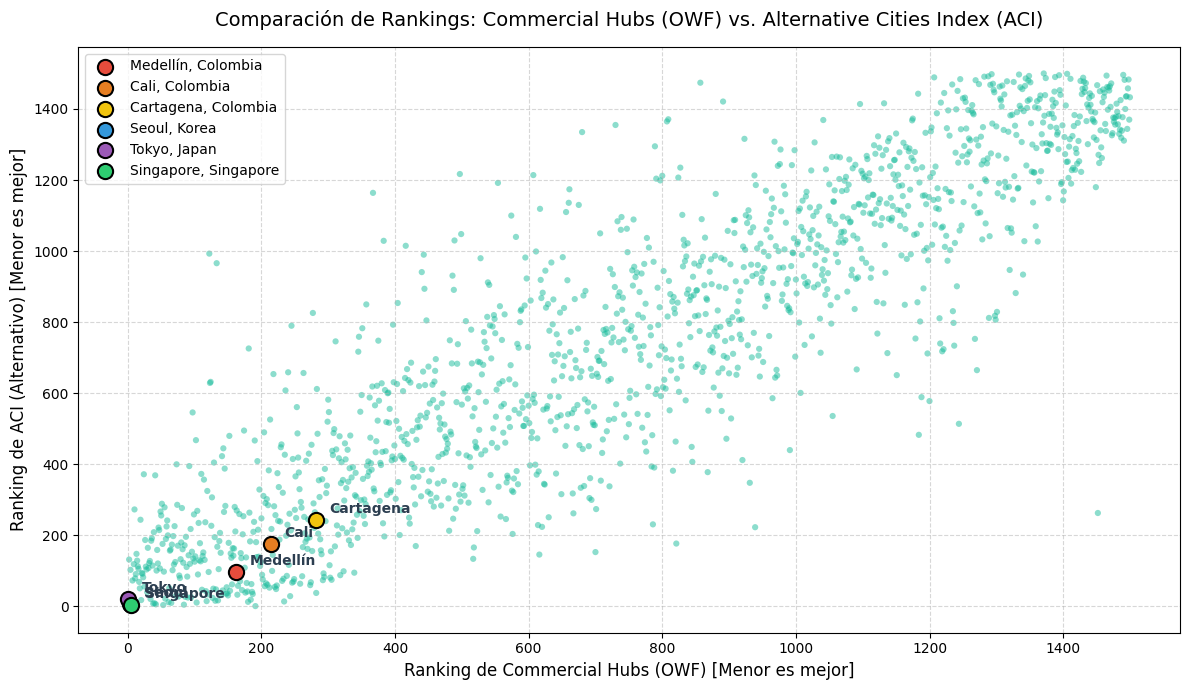

In [15]:
# 2. Graficar la comparación de Ranks (Commercial Hubs vs ACI Rank)
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_merged, x='Commercial Hubs', y='ACI_Rank', alpha=0.5, color='#1abc9c', edgecolor='none', s=20)
plt.title('Comparación de Rankings: Commercial Hubs (OWF) vs. Alternative Cities Index (ACI)', fontsize=14, pad=15)
plt.xlabel('Ranking de Commercial Hubs (OWF) [Menor es mejor]', fontsize=12)
plt.ylabel('Ranking de ACI (Alternativo) [Menor es mejor]', fontsize=12)

# Destacar ciudades del Sur Global y casos extremos
ciudades_destacar = ['Medellín, Colombia', 'Cali, Colombia', 'Cartagena, Colombia', 'Seoul, Korea', 'Tokyo, Japan', 'Singapore, Singapore']
colores_destacados = {
    'Medellín, Colombia': '#e74c3c', 
    'Cali, Colombia': '#e67e22', 
    'Cartagena, Colombia': '#f1c40f', 
    'Seoul, Korea': '#3498db', 
    'Tokyo, Japan': '#9b59b6', 
    'Singapore, Singapore': '#2ecc71'
}

for city in ciudades_destacar:
    row = df_merged[df_merged['City'] == city]
    if not row.empty:
        plt.scatter(
            row['Commercial Hubs'].values[0], row['ACI_Rank'].values[0],
            color=colores_destacados[city], s=120, edgecolor='black', linewidth=1.5, zorder=5, label=city
        )
        plt.annotate(
            city.split(',')[0],
            (row['Commercial Hubs'].values[0], row['ACI_Rank'].values[0]),
            textcoords="offset points", xytext=(10, 5),
            fontsize=10, weight='bold', color='#2c3e50'
        )

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

